In [ ]:
import numpy as np

A = np.array([[2],
              [3],
              [5]])

b = np.array([5, 1, 3])

x_lstsq, residuals, rank, s = np.linalg.lstsq(A, b, rcond=None)

print("Optimal x =", x_lstsq[0])
print("Residual =", residuals)

Optimal x = 0.7368421052631576
Residual = [14.36842105]


In [ ]:
from scipy.optimize import least_squares
import numpy as np

def residual(x):
    return np.array([
        2*x[0] - 5,
        3*x[0] - 1,
        5*x[0] - 3
    ])

x0 = np.array([0.0])

result = least_squares(residual, x0)

print("Optimal x =", result.x[0])
print("Cost =", result.cost)
print("Number of iterations =", result.nfev)

Optimal x = 0.7368421052631576
Cost = 7.18421052631579
Number of iterations = 2


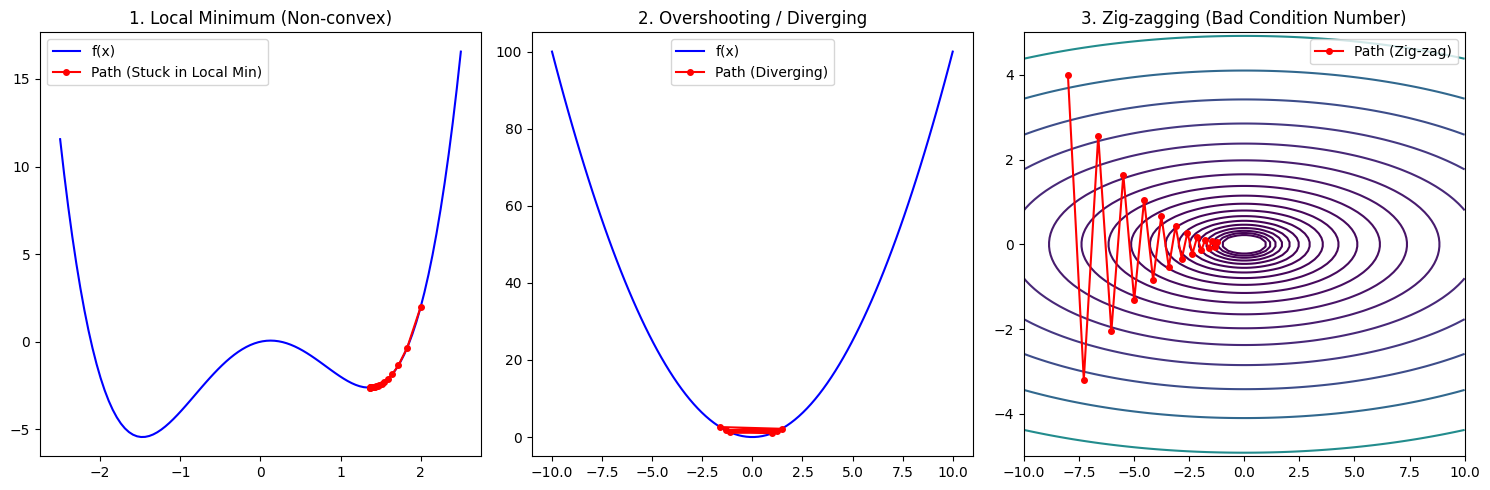

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def gradient_descent(grad_f, x_init, lr, iterations):
    x_history = [x_init]
    x = x_init
    for _ in range(iterations):
        x = x - lr * grad_f(x)
        x_history.append(x)
    return np.array(x_history)

fig = plt.figure(figsize=(15, 5))

# ==========================================
# ケース1: 局所最適解に捕まる（非凸関数）
# f(x) = x^4 - 4x^2 + x
# ==========================================
ax1 = fig.add_subplot(131)
x_vals = np.linspace(-2.5, 2.5, 100)
f1 = lambda x: x**4 - 4*x**2 + x
grad_f1 = lambda x: 4*x**3 - 8*x + 1

# スタート地点を右側にすると、右側の浅い谷（局所解）に捕まる
history1 = gradient_descent(grad_f1, x_init=2.0, lr=0.01, iterations=20)
ax1.plot(x_vals, f1(x_vals), label="f(x)", color="blue")
ax1.plot(history1, f1(history1), 'ro-', markersize=4, label="Path (Stuck in Local Min)")
ax1.set_title("1. Local Minimum (Non-convex)")
ax1.legend()

# ==========================================
# ケース2: 発散する（学習率が大きすぎる）
# f(x) = x^2
# ==========================================
ax2 = fig.add_subplot(132)
x_vals = np.linspace(-10, 10, 100)
f2 = lambda x: x**2
grad_f2 = lambda x: 2*x

# 学習率 lr=1.1 だと、谷を飛び越えて徐々に発散していく
history2 = gradient_descent(grad_f2, x_init=1.0, lr=1.05, iterations=5)
ax2.plot(x_vals, f2(x_vals), label="f(x)", color="blue")
ax2.plot(history2, f2(history2), 'ro-', markersize=4, label="Path (Diverging)")
ax2.set_title("2. Overshooting / Diverging")
ax2.legend()

# ==========================================
# ケース3: ジグザグに進む（条件数が悪い）
# f(x, y) = x^2 + 20y^2
# ==========================================
ax3 = fig.add_subplot(133)
x_vals = np.linspace(-10, 10, 100)
y_vals = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(x_vals, y_vals)
Z = X**2 + 20 * Y**2  # y方向だけ極端に急な谷

# 2変数の勾配降下法
def grad_f3(pos):
    return np.array([2*pos[0], 40*pos[1]])

pos_history = [np.array([-8.0, 4.0])]
pos = pos_history[0]
lr3 = 0.045
for _ in range(20):
    pos = pos - lr3 * grad_f3(pos)
    pos_history.append(pos)
pos_history = np.array(pos_history)

ax3.contour(X, Y, Z, levels=np.logspace(0, 3, 20), cmap='viridis')
ax3.plot(pos_history[:, 0], pos_history[:, 1], 'ro-', markersize=4, label="Path (Zig-zag)")
ax3.set_title("3. Zig-zagging (Bad Condition Number)")
ax3.legend()

plt.tight_layout()
plt.show()